Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. Никто вас не ограничивает в наведении красоты, но требуется выполнение того, что в задании.

Это последняя домашка на код! Здесь вам нужно будет сделать читаемый ноутбук с ответами на вопросы и выполнением заданий.
***

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from geopy.distance import geodesic
import json

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Данные (3 pt)

## Обычные данные (2 pt)

Как понятно по названию — фокусом этой домашки будут **геоданные**. Не то, чтобы эти данные как-то принципиально отличаются от всех других, просто они имеют весьма конкретное значение. 

> В этом задании сделаем упор на **визуализацию и бизнесовую интерпретацию** данных.

В качестве данных возьмем информацию о [поездках на такси в Нью-Йорке](https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data?select=yellow_tripdata_2016-03.csv) за март 2016 года. Однако полный датасет имеет размер `(12210952, 19)`, что для нас слишком много, поэтому ограничимся только _одним днем_ и не всеми колонками.

In [2]:
df = pd.read_csv('yellow_tripdata_2016-03-01.csv')
print(df.shape)
df.head()

(372868, 10)


,tpep_pickup_datetime,tpep_dropoff_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_distance,passenger_count,fare_amount,total_amount
0,2016-03-01 00:00:00,2016-03-01 00:07:55,-73.976746,40.765152,-74.004265,40.746128,2.50,1,9.0,12.35
1,2016-03-01 00:00:00,2016-03-01 00:11:06,-73.983482,40.767925,-74.005943,40.733166,2.90,1,11.0,15.35
2,2016-03-01 00:00:00,2016-03-01 00:31:06,-73.782021,40.644810,-73.974541,40.675770,19.98,2,54.5,63.80
3,2016-03-01 00:00:00,2016-03-01 00:00:00,-73.863419,40.769814,-73.969650,40.757767,10.78,3,31.5,41.62
4,2016-03-01 00:00:00,2016-03-01 00:00:00,-73.971741,40.792183,-74.177170,40.695053,30.43,5,98.0,113.80


**ЗАДАНИЕ**

Изучите данные, поймите названия столбцов и проверьте/обработайте ошибки и пропуски в данных.

In [3]:
df.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'trip_distance', 'passenger_count', 'fare_amount', 'total_amount'],
      dtype='object')

In [ ]:
...

**ЗАДАНИЕ**

Для анализа нам точно понадобится знать еще и длительность и расстояния поездок, поэтому давайте создадим столбцы `trip_duration` и `distance_between_points`: длительность (в минутах) и расстояние между пунктом начала и назначения соответственно.

Понятно, что евклидово расстояние считать не совсем честно (не плоская земля все же), поэтому воспользуемся `geopy.distance.geodesic`, которая по-умному все посчитает за нас) _Не забудьте перевести все в те единицы измерения, в которых расстояние в данных, чтобы можно было сравнивать._

In [ ]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# не забудьте и тут убрать странные поездки, например с нулевым или отрицательным временем

df['trip_duration'] = ...

def get_dist(row):
    ...
    dist = geodesic(...)...
    return dist

df['distance_between_points'] = df.apply(get_dist, axis=1)

df.shape

**ЗАДАНИЕ**

Также для будущего удобства давайте создадим столбец `pickup_hour`, в которо целым числом отметим, в каком часу (0-23) была начата поездка. И еще столбец `cost_per_mile` — стоимость мили в этой поездке (считать по расстоянию поездки). Это нам пригодится для визуализации.

In [ ]:
df['pickup_hour'] = ...

df['cost_per_mile'] = ...

df = df.dropna(subset=['pickup_hour', 'cost_per_mile'])
df.shape

_Нам еще понадобятся преобразования данных, но будем их делать чуть позже_

## Необычные данные (1 pt)

Данные о поездках у нас есть, но как их «подружить» со знаниями о городе? Можно через какое-нибудь API получать адреса по геопозиции, но это довольно долго и иногда небесплатно для учебной задачи, поэтому будем работать с новым форматом данных и знаниями о **районах города**.

Для этого дела нам понадобится библиотека `geopandas`, вот [русский гайд](https://habr.com/ru/articles/515328/),
а вот ваша любимая [документация](https://geopandas.org/en/stable/) (и даже [гит](https://github.com/geopandas/geopandas)). Она нам сильно не понадобится, но вдруг вам интересно.

In [4]:
gdf = gpd.read_file('Borough_Boundaries_nyc.geojson').to_crs("EPSG:4326")
gdf

,:id,:version,:created_at,:updated_at,borocode,boroname,shape_area,shape_leng,geometry
0,row-sn28~av3k.vwsa,rv-665b-x5bf.pjx5,2026-03-09 20:59:40.758000+00:00,2026-03-09 20:59:40.758000+00:00,5,Staten Island,1623618358.46,325912.288988,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ..."
1,row-g9mx.4xiy-tp3g,rv-f783_n7nw_4zya,2026-03-09 20:59:40.758000+00:00,2026-03-09 20:59:40.758000+00:00,1,Manhattan,636631650.451,359537.866079,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ..."
2,row-2e6v~vna8_nnub,rv-xhj4.y6me_fsbi,2026-03-09 20:59:40.758000+00:00,2026-03-09 20:59:40.758000+00:00,2,Bronx,1187199300.36,463147.071867,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ..."
3,row-z4zg_8qgh.py9g,rv-c5dp~tszd.xcv4,2026-03-09 20:59:40.758000+00:00,2026-03-09 20:59:40.758000+00:00,3,Brooklyn,1934462607.43,726953.044632,"MULTIPOLYGON (((-73.86327 40.58388, -73.86381 ..."
4,row-ii38~xmid.7jq2,rv-99dx-r5hs.vcwe,2026-03-09 20:59:40.758000+00:00,2026-03-09 20:59:40.758000+00:00,4,Queens,3041419178.99,887905.076018,"MULTIPOLYGON (((-73.82645 40.59053, -73.82642 ..."


Нам интереснее всего последний столбец, который задает **геометрию районов**. С помощью него мы сможем **групировать наши большие данные по районам** и делать более комплексный анализ.

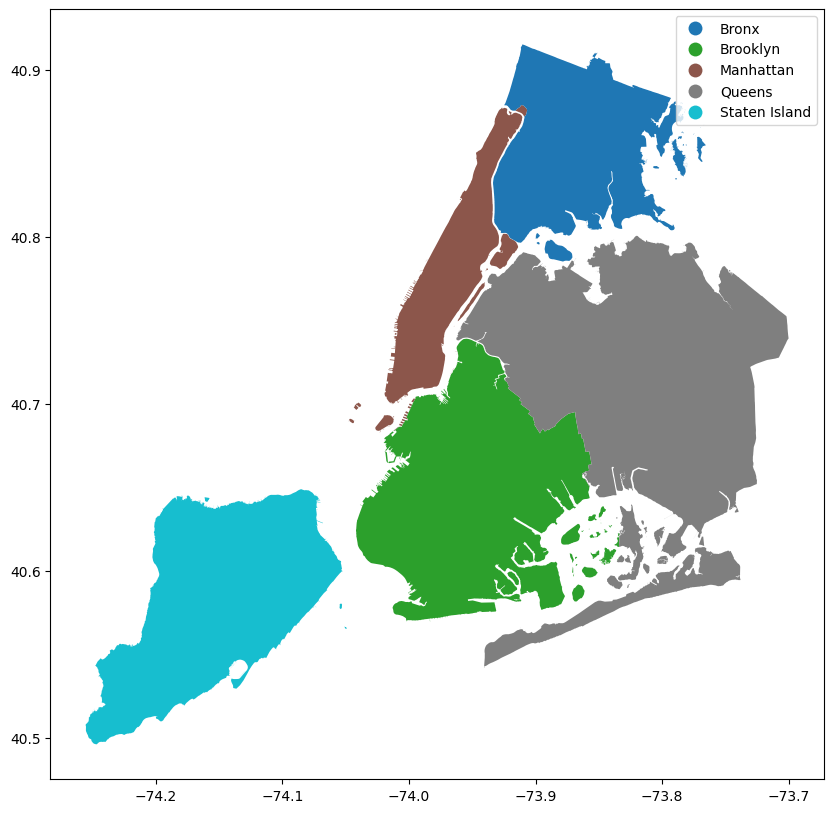

In [5]:
gdf.plot(column='boroname', legend=True, figsize=(10, 10))
plt.show()

**ЗАДАНИЕ**

Давайте теперь соединим наши данные и добавим столбцы `pickup_district` и `dropoff_district` с названиями районов.

Для этого будем дейстовать по такому алгоритму
1. Создадим `gpd.GeoDataFrame` для точек старта и финиша, то есть приведем к понятному для геопандаса виду. Для этого нужно передать в параметр `geometry` объект точки (объект геопандаса), используйте для этого [`gpd.points_from_xy`](https://geopandas.org/en/stable/docs/reference/api/geopandas.points_from_xy.html) _<- это ссылка_.
2. Сопоставим названия райнов и точек. Для этого надо передать наши точки и данные из районов, а именно имя и геометрию. Используйте для этого [`gpd.sjoin`](https://geopandas.org/en/v1.1.2/docs/reference/api/geopandas.sjoin.html) _<- это тоже ссылка_.
3. Создаем новый столбец в наших данных (просто переклеиваем столбез из прошлого пункта).
4. Убираем точки вне районов (можно поставить специальный маркер, но он может потом помешать при визуализайии).

In [ ]:
gdf_pickup = gpd.GeoDataFrame(df, geometry=..., crs="EPSG:4326")
gdf_dropoff = gpd.GeoDataFrame(df, geometry=..., crs="EPSG:4326")

pickup_join = gpd.sjoin(..., how='left', predicate='within')
dropoff_join = gpd.sjoin(..., how='left', predicate='within')

df['pickup_district'] = ...
df['dropoff_district'] = ...

df = df.dropna(subset=['pickup_district', 'dropoff_district'])
df.shape

In [ ]:
# посмотрим статистику по районам
df['pickup_district'].value_counts()

_Возможно нам что-то еще нужно поделать с данными, но базово мы готовы к визуализации и анализу._

# Визуализация аля крутые (2 pt)

Понятно, что мы бы могли проанализировать все так, как мы уже умеем: нарисовать гистограммы, плоты, посмотреть корреляциии и частоты. Это все важно и нужно (без этого качество точно пострадает), но мы же хотим новому научиться, поэтому тут будем делать **анализ только по одному графику**!  
_Но мы же хотим хороший анализ, поэтому нужен ооочень хороший график:)_

**ЗАДАНИЕ**

Нарисовать **интерактивный график** (сохранить его в `html` и сдать также как и в 5й домашке, ПРОВЕРЬТЕ, ЧТО Я СМОГУ ЕГО ОТКРЫТЬ, ЕСЛИ НЕТ, ТО ХОТЯ БЫ СКРИНЫ НАДО), который будет:  
* иметь пять связанных графиков — основной с картой (да, все должно быть наложено на карту) и четыре с разными графиками на ваш выбор.

_**на основном**_:  
1. отображать `pickup` и `dropoff` точки разными способами (цвета, заливка или что-то еще — выберите сами) на реальной карте;
2. иметь **ховер по точкам** — подробная информация о поездке;
3. иметь **фильтрацию по районам** отправления;

_**на остальных (связаны через выбор района)**_:
1. плоты или скаттерплоты, отображающие информацию;
2. тот же самый ховер, что и на основном графике.
* На этих графиках можно отразить: `час vs количество пассажиров`, `дистанция (такси) vs расстояние`, `стоимость vs дистанция`, `длительность vs расстояние между точками`, и все, что вам кажется логичным посмотреть.

_Не буду заставлять все это делать с нуля, верю, что вы разобрались в пятой домашке, поэтому оставлю свой шаблон, если хотите, добавляйте что-то._

In [ ]:
df['pickup_time_str'] = df['tpep_pickup_datetime'].dt.strftime('%Y-%m-%d %H:%M')
df['dropoff_time_str'] = df['tpep_dropoff_datetime'].dt.strftime('%Y-%m-%d %H:%M')
districts = sorted(df['pickup_district'].unique())

def prepare_custom_data(sub_df):
    return np.column_stack([
        sub_df['pickup_district'],
        sub_df['pickup_time_str'],
        sub_df['dropoff_district'],
        sub_df['dropoff_time_str'],
        sub_df['trip_duration'],
        sub_df['fare_amount'],
        sub_df['trip_distance'],
        sub_df['distance_between_points'],
        sub_df['passenger_count']
    ])

hover_template = """
Старт: %{customdata[0]} (%{customdata[1]})<br>
Финиш: %{customdata[2]} (%{customdata[3]})<br>
Длительность: %{customdata[4]:.1f} мин<br>
Стоимость: $%{customdata[5]:.2f}<br>
Дистанция: %{customdata[6]:.2f} миль<br>
Расстояние между точками: %{customdata[7]:.3f}<br>
Пассажиры: %{customdata[8]}<extra></extra>
"""

fig = make_subplots(
    rows=2, cols=3,
    column_widths=[0.3, 0.4, 0.3],
    row_heights=[0.5, 0.5],
    specs=[
        [{"type": "scatter"}, {"type": "map", "rowspan": 2}, {"type": "scatter"}],
        [{"type": "scatter"}, None, {"type": "scatter"}]
    ],
    subplot_titles=(
        "Час vs Пассажиры",
        "",
        "Дистанция (такси) vs Евклид. дист",
        "Стоимость vs Дистанция",
        "Длительность vs Евклид. Дист"
    ),
    vertical_spacing=0.08,
    horizontal_spacing=0.05
)

num_d = len(districts)
total_traces = num_d * 6 

# генерация трейсов для каждого района для работы списка
for i, d in enumerate(districts):
    # будем брать для отображения только некоторые точки, иначе плотли ляжет,
    # можете и без этого, если боитесь потерять данные
    sub_df_map = df[df['pickup_district'] == d].sample(min(3000, len(df[df['pickup_district']==d])), random_state=42)
    sub_df = df[df['pickup_district'] == d].sample(min(6000, len(df[df['pickup_district']==d])), random_state=42)
    cd = prepare_custom_data(sub_df)

    # ЦЕНТР
    # 1. Точки отправления
    fig.add_trace(go.Scattermap(
        lat=sub_df_map['pickup_latitude'], lon=sub_df_map['pickup_longitude'],
        mode='markers', marker=dict(size=4, color='blue', opacity=0.6),
        name=f'{d} Pickup', visible=False,
        text=sub_df_map['pickup_district'], customdata=cd,
        hovertemplate=hover_template
    ), row=1, col=2)

    # 2. Точки прибытия
    fig.add_trace(go.Scattermap(
        lat=sub_df_map['dropoff_latitude'], lon=sub_df_map['dropoff_longitude'],
        mode='markers', marker=dict(size=4, color='orange', opacity=0.6, symbol='cross'),
        name=f'{d} Dropoff', visible=False,
        text=sub_df_map['dropoff_district'], customdata=cd,
        hovertemplate=hover_template
    ), row=1, col=2)

    # ЛЕВАЯ КОЛОНКА
    # 3
    fig.add_trace(go.Scatter(
        x=..., y=...,
        mode='markers', name=d, visible=False,
        marker=dict(size=5, opacity=0.7, color=...),
        customdata=cd, hovertemplate=hover_template
    ), row=1, col=1)

    # 4
    fig.add_trace(go.Scatter(
        x=..., y=...,
        mode='markers', name=d, visible=False,
        marker=dict(size=5, opacity=0.7, color=...),
        customdata=cd, hovertemplate=hover_template
    ), row=2, col=1)

    # ПРАВАЯ КОЛОНКА
    # 5
    fig.add_trace(go.Scatter(
        x=..., y=...,
        mode='markers', name=d, visible=False,
        marker=dict(size=5, opacity=0.7, color=...),
        customdata=cd, hovertemplate=hover_template
    ), row=1, col=3)

    # 6
    fig.add_trace(go.Scatter(
        x=..., y=...,
        mode='markers', name=d, visible=False,
        marker=dict(size=5, opacity=0.7, color=...),
        customdata=cd, hovertemplate=hover_template
    ), row=2, col=3)


buttons = []

buttons.append(dict(
    label="Все районы",
    method="update",
    args=[{"visible": [True] * total_traces}]
))

# кнопки для каждого района
for i, d in enumerate(districts):
    base_idx = i * 6
    vis_list = [False] * total_traces
    for j in range(6):
        vis_list[base_idx + j] = True

    buttons.append(dict(label=d, method="update", args=[{"visible": vis_list}]))

fig.update_layout(
    updatemenus=[dict(
        buttons=buttons, 
        direction="down", 
        showactive=True, 
        x=0.5, y=1.05, xanchor="center", yanchor="top",
        bgcolor="rgba(255,255,255,0.95)", borderwidth=1, font=dict(size=12),
        active=0
    )],
    map=dict(style="carto-positron", center=dict(lat=40.7128, lon=-74.0060), zoom=10), # КАРТА!
    height=900, 
    showlegend=False, 
    template="plotly_white"
)

**НЕ ЗАБУДЬТЕ СОХРАНИТЬ**

# Анализ и выводы (5 pt)

Ну и когда все готова ваш любимы анализ в последний раз!

Вам нужно сделать **10 выводов и/или наблюдений**. Четыре из них должны касаться **длительности поездки, количества человек, пунктов назначения, стоимости поездки**. Остальные выводы полностью на ваше усмотрение. Выводы должны быть подкреплены визуально: то есть должно быть понятно, **куда смотреть**, чтобы увидеть (и **как увидеть**: _плотность точек, положение по какой-то оси или что-то еще_).

_Действовать стоит так: увидеть что-то на интерактивном графике, если это плохо видно или сомнительно, то нарисовать в этой части статический и показать на нем._

СДЕЛАЙТЕ СТРУКТУРУ У ЭТОЙ ЧАСТИ, ЧТОБЫ ПОНЯТНО БЫЛО, КАК ЕЕ ЧИТАТЬ. ДА, СТРУКТУРУ НАДО ДЕЛАТЬ ДАЖЕ ЕСЛИ ЭТО ВСЕ ЗАНИМАЕТ МАЛО СТРОК!

***
Это все, ты молодец &#10084;